In [4]:
import os
import json
from pathlib import Path

import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from google.colab import drive

# Mount Google Drive to read dataset and store artifacts
drive.mount('/content/drive')

# Project root in Google Drive
project_folder = '/content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# 1. Load dataset
print('Loading data from Google Drive...')
data_path = os.path.join(project_folder, 'data/proceed/micro_mobility_training_data_2025_v2.csv')
print('data_path:', data_path)

df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'])
if 'datetime_hour' in df.columns:
    df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

# Optional: station identity feature (helps location-specific patterns)
if 'station' in df.columns and 'station_id' not in df.columns:
    df['station_id'] = pd.factorize(df['station'])[0].astype('int32')

# Strict chronological ordering
sort_cols = ['datetime_hour', 'station'] if 'datetime_hour' in df.columns else ['date', 'hour']
df = df.sort_values(by=sort_cols).reset_index(drop=True)

print('rows:', len(df), '| columns:', len(df.columns))


Loading data from Google Drive...
data_path: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2025_v2.csv
rows: 4254919 | columns: 19


In [6]:
# 2. Define features (X) and target (y)
feature_columns = [
    'station_id',
    'hour', 'lat', 'lng',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos',
    'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h'
]
target_column = 'net_demand'

missing = [c for c in feature_columns + [target_column] if c not in df.columns]
if missing:
    raise ValueError(f'Missing required columns: {missing}')

X = df[feature_columns]
y = df[target_column]

print('Using features:', feature_columns)


Using features: ['station_id', 'hour', 'lat', 'lng', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_24h', 'rolling_mean_3h']


In [7]:
# 3. Chronological train/test split (last 7 days as holdout)
if 'datetime_hour' in df.columns:
    cutoff_ts = df['datetime_hour'].max() - pd.Timedelta(days=7)
    train_mask = df['datetime_hour'] <= cutoff_ts
    test_mask = df['datetime_hour'] > cutoff_ts
    print('cutoff_ts:', cutoff_ts)
else:
    cutoff_date = df['date'].max() - pd.Timedelta(days=7)
    train_mask = df['date'] <= cutoff_date
    test_mask = df['date'] > cutoff_date
    print('cutoff_date:', cutoff_date)

X_train, y_train = X.loc[train_mask], y.loc[train_mask]
X_test, y_test = X.loc[test_mask], y.loc[test_mask]

print(f'Training on {len(X_train)} rows...')
print(f'Testing on {len(X_test)} rows...')
print(f'Test zero ratio: {(y_test == 0).mean():.4f}')


cutoff_ts: 2025-12-24 23:00:00
Training on 4173103 rows...
Testing on 81816 rows...
Test zero ratio: 0.9465


In [8]:
# 4. Training + artifact configuration

total_trees = 100
run_training = True  # Set False to skip fit() and load saved artifacts for reporting

xgb_params = dict(
    n_estimators=total_trees,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1,
)

artifact_dir = os.path.join(project_folder, 'artifacts', 'model_training', 'xgb', 'v2_0')
os.makedirs(artifact_dir, exist_ok=True)

model_artifact_path = os.path.join(artifact_dir, 'xgb_model.json')
metrics_artifact_path = os.path.join(artifact_dir, 'metrics.json')
feature_importance_path = os.path.join(artifact_dir, 'feature_importance_gain.csv')
predictions_artifact_path = os.path.join(artifact_dir, 'test_predictions.parquet')

print('artifact_dir:', artifact_dir)
print('run_training:', run_training)


artifact_dir: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/xgb/v2_0
run_training: True


In [9]:
# 5. Train model OR load saved model artifact
if run_training:
    model = xgb.XGBRegressor(**xgb_params)
    model.fit(X_train, y_train)
    final_model = model
    final_model.save_model(model_artifact_path)
    print('Training complete.')
    print('Saved model artifact:', model_artifact_path)
else:
    if not os.path.exists(model_artifact_path):
        raise FileNotFoundError(
            f'Model artifact not found: {model_artifact_path}. Run with run_training=True first.'
        )
    final_model = xgb.XGBRegressor()
    final_model.load_model(model_artifact_path)
    print('Loaded model artifact:', model_artifact_path)


Training complete.
Saved model artifact: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/xgb/v2_0/xgb_model.json


In [10]:
# 6. Evaluation + baselines + save artifacts
pred = final_model.predict(X_test)

def metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return rmse, mae, r2

rmse, mae, r2 = metrics(y_test, pred)

print('\n--- Model Performance (All Test Rows) ---')
print(f'RMSE: {rmse:.4f}')
print(f'MAE : {mae:.4f}')
print(f'R^2 : {r2:.4f}')

# Baselines
baseline_zero = np.zeros(len(y_test), dtype=np.float32)
baselines = {
    'zero': baseline_zero,
    'lag_1h': X_test['lag_1h'].to_numpy(),
    'lag_24h': X_test['lag_24h'].to_numpy(),
    'rolling_mean_3h': X_test['rolling_mean_3h'].to_numpy(),
}

baseline_metrics = {}
print('\n--- Baseline Comparison (All Test Rows) ---')
for name, bp in baselines.items():
    b_rmse, b_mae, b_r2 = metrics(y_test, bp)
    baseline_metrics[name] = {'rmse': b_rmse, 'mae': b_mae, 'r2': b_r2}
    print(f'{name:16s} RMSE={b_rmse:.4f} MAE={b_mae:.4f} R^2={b_r2:.4f}')

# Non-zero subset metrics (more informative on sparse target)
nonzero_mask = y_test != 0
nonzero_metrics = None
if nonzero_mask.sum() > 0:
    nz_rmse, nz_mae, nz_r2 = metrics(y_test[nonzero_mask], pred[nonzero_mask])
    nonzero_metrics = {
        'rows': int(nonzero_mask.sum()),
        'rmse': nz_rmse,
        'mae': nz_mae,
        'r2': nz_r2,
    }
    print('\n--- Model Performance (Non-zero Test Rows) ---')
    print(f'Rows: {int(nonzero_mask.sum())} / {len(y_test)}')
    print(f'RMSE: {nz_rmse:.4f}')
    print(f'MAE : {nz_mae:.4f}')
    print(f'R^2 : {nz_r2:.4f}')

# Save prediction artifact for future reporting (no retraining required)
pred_df = pd.DataFrame({
    'y_true': y_test.to_numpy(),
    'y_pred': pred,
    'lag_1h': X_test['lag_1h'].to_numpy(),
    'lag_24h': X_test['lag_24h'].to_numpy(),
    'rolling_mean_3h': X_test['rolling_mean_3h'].to_numpy(),
})
if 'datetime_hour' in df.columns:
    pred_df['datetime_hour'] = df.loc[test_mask, 'datetime_hour'].to_numpy()
if 'date' in df.columns:
    pred_df['date'] = df.loc[test_mask, 'date'].to_numpy()
if 'station' in df.columns:
    pred_df['station'] = df.loc[test_mask, 'station'].to_numpy()

pred_df.to_parquet(predictions_artifact_path, index=False)
print('Saved predictions artifact:', predictions_artifact_path)

# Save metrics artifact
metrics_artifact = {
    'data_path': data_path,
    'feature_columns': feature_columns,
    'target_column': target_column,
    'train_rows': int(len(X_train)),
    'test_rows': int(len(X_test)),
    'test_zero_ratio': float((y_test == 0).mean()),
    'model_metrics': {'rmse': rmse, 'mae': mae, 'r2': r2},
    'baseline_metrics': baseline_metrics,
    'nonzero_metrics': nonzero_metrics,
    'xgb_params': xgb_params,
    'model_artifact_path': model_artifact_path,
    'predictions_artifact_path': predictions_artifact_path,
}
with open(metrics_artifact_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_artifact, f, indent=2)
print('Saved metrics artifact:', metrics_artifact_path)



--- Model Performance (All Test Rows) ---
RMSE: 0.3675
MAE : 0.0851
R^2 : 0.0402

--- Baseline Comparison (All Test Rows) ---
zero             RMSE=0.3751 MAE=0.0747 R^2=0.0000
lag_1h           RMSE=0.5158 MAE=0.1184 R^2=-0.8911
lag_24h          RMSE=0.4992 MAE=0.1186 R^2=-0.7713
rolling_mean_3h  RMSE=0.4260 MAE=0.1038 R^2=-0.2901

--- Model Performance (Non-zero Test Rows) ---
Rows: 4375 / 81816
RMSE: 1.5624
MAE : 1.3431
R^2 : 0.0721
Saved predictions artifact: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/xgb/v2_0/test_predictions.parquet
Saved metrics artifact: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/xgb/v2_0/metrics.json



Plotting feature importance...
Saved feature importance artifact: /content/drive/MyDrive/AIT/ML/citibike-netdemand-prediction/artifacts/model_training/xgb/v2_0/feature_importance_gain.csv


,feature,gain
0,lag_24h,7924.298340
1,lag_1h,3178.431641
2,hour_sin,2606.401611
3,day_sin,1903.752441
4,hour,1516.900024
5,hour_cos,1270.408203
6,rolling_mean_3h,1059.925049
7,day_cos,752.457581
8,lat,645.364319
9,lng,594.397522


<Figure size 1000x600 with 0 Axes>

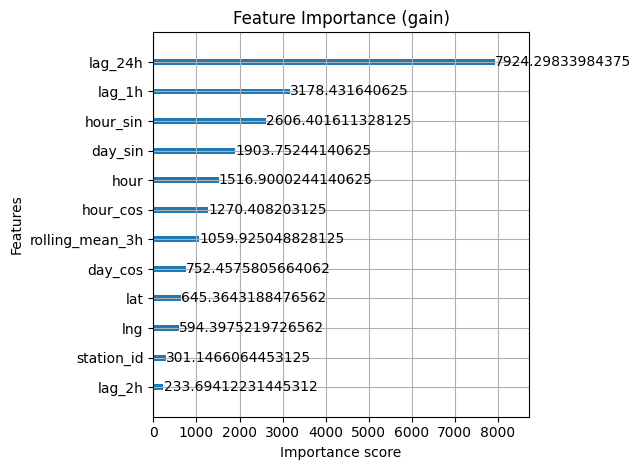

In [11]:
# 7. Feature importance + save artifact
print('\nPlotting feature importance...')

booster = final_model.get_booster()
score_gain = booster.get_score(importance_type='gain')
fi_gain = (
    pd.DataFrame({'feature': list(score_gain.keys()), 'gain': list(score_gain.values())})
    .sort_values('gain', ascending=False)
    .reset_index(drop=True)
)

fi_gain.to_csv(feature_importance_path, index=False)
print('Saved feature importance artifact:', feature_importance_path)

display(fi_gain.head(15))

plt.figure(figsize=(10, 6))
xgb.plot_importance(final_model, importance_type='gain', max_num_features=12, title='Feature Importance (gain)')
plt.tight_layout()
plt.show()


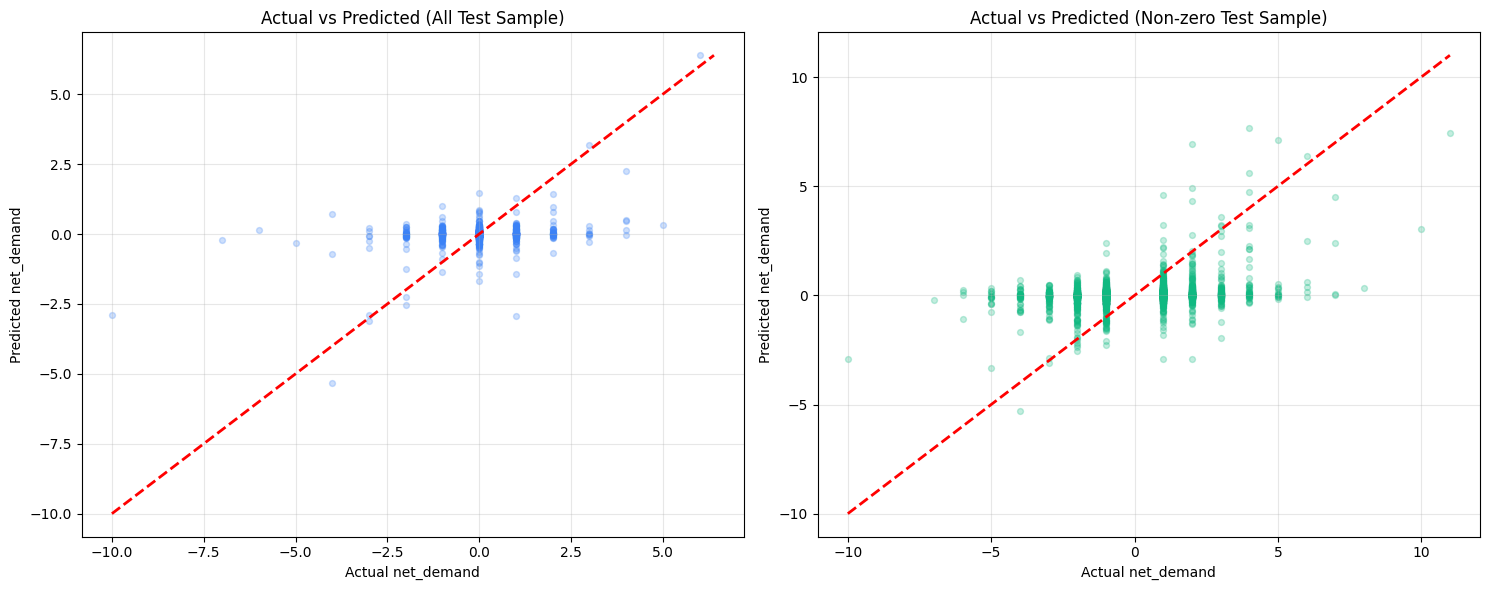

In [12]:
# 8. Prediction diagnostics plots + artifact-only reload helper

# Set True when you want to regenerate plots from saved artifacts without model inference
load_predictions_from_artifact = False

if load_predictions_from_artifact:
    if not os.path.exists(predictions_artifact_path):
        raise FileNotFoundError(
            f'Predictions artifact not found: {predictions_artifact_path}. Run evaluation once first.'
        )
    pred_df = pd.read_parquet(predictions_artifact_path)
    y_true_arr = pred_df['y_true'].to_numpy()
    y_pred_arr = pred_df['y_pred'].to_numpy()
else:
    y_true_arr = y_test.to_numpy()
    y_pred_arr = pred

# Sample points for plotting
sample_size = min(8000, len(y_true_arr))
sample_idx = np.random.default_rng(42).choice(len(y_true_arr), size=sample_size, replace=False)

y_true_sample = y_true_arr[sample_idx]
y_pred_sample = y_pred_arr[sample_idx]

# Non-zero sample for clearer view
nz_idx_all = np.where(y_true_arr != 0)[0]
if len(nz_idx_all) > 0:
    nz_sample_size = min(8000, len(nz_idx_all))
    nz_sample_idx = np.random.default_rng(42).choice(nz_idx_all, size=nz_sample_size, replace=False)
    y_true_nz = y_true_arr[nz_sample_idx]
    y_pred_nz = y_pred_arr[nz_sample_idx]
else:
    y_true_nz = np.array([])
    y_pred_nz = np.array([])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# All rows scatter
axes[0].scatter(y_true_sample, y_pred_sample, alpha=0.25, s=18, color='#3b82f6')
mn = float(min(y_true_sample.min(), y_pred_sample.min()))
mx = float(max(y_true_sample.max(), y_pred_sample.max()))
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted (All Test Sample)')
axes[0].set_xlabel('Actual net_demand')
axes[0].set_ylabel('Predicted net_demand')
axes[0].grid(alpha=0.3)

# Non-zero rows scatter
if len(y_true_nz) > 0:
    axes[1].scatter(y_true_nz, y_pred_nz, alpha=0.25, s=18, color='#10b981')
    mn2 = float(min(y_true_nz.min(), y_pred_nz.min()))
    mx2 = float(max(y_true_nz.max(), y_pred_nz.max()))
    axes[1].plot([mn2, mx2], [mn2, mx2], 'r--', lw=2)
    axes[1].set_title('Actual vs Predicted (Non-zero Test Sample)')
    axes[1].set_xlabel('Actual net_demand')
    axes[1].set_ylabel('Predicted net_demand')
    axes[1].grid(alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'No non-zero rows in test set', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()
